# Glossary
__TLT iShares 20+ Year Treasury Bond ETF__
- tracks long-term (20+ years) US Treasury bonds
- Highly sensitive to interest rate changes (duration)
- No credit risk
- __Usage__:proxy for long-end yields / macro rate expectations 

__SHY iShares 1-3 Year Treasury Bond ETF__
- Tracks short-term (1–3 year) US Treasury bonds
- Low volatility, closely tied to Fed policy
- No credit risk
- __Use__: proxy for short-end rates / policy stance

__LQD iShares iBoxx $ Investment Grade Corporate Bond ETF__
- Tracks investment-grade corporate bonds
- Exposed to both interest rates and credit spreads
- Moderate risk
- __Use__: gauge of healthy corporate credit conditions

__JNK SPDR Bloomberg High Yield Bond ETF__
- Tracks high-yield (junk) corporate bonds
- High sensitivity to economic conditions and defaults
- Correlated with equities
- __Use__: proxy for risk appetite / credit risk

__HYG iShares iBoxx $ High Yield Corporate Bond ETF__
- Similar to JNK (high-yield corporate bonds)
- Slight differences in composition/liquidity
- High credit risk
- __Use__: confirmation of risk-on / risk-off environment

__Key Interpretation__
- __TLT vs SHY__ → yield curve / rates dynamics
- __LQD vs TLT__ → investment-grade credit spreads
- __HYG / JNK vs LQD__ → risk appetite and credit stress

# Step 1 - imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (12, 6)

# Step 2 - Load Excel file

In [3]:
file_path = "../data/corporate_bonds/corporate_bonds.xlsx"
sheet_name = "daily"

df = pd.read_excel(file_path, sheet_name=sheet_name)
#Clean the date column
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").reset_index(drop=True)
df.set_index("Date", inplace=True)
#Check structure and view missing data
#df.tail()
#df.info()
#df.isna().sum()


# Step 3 - Plot the raw yield series

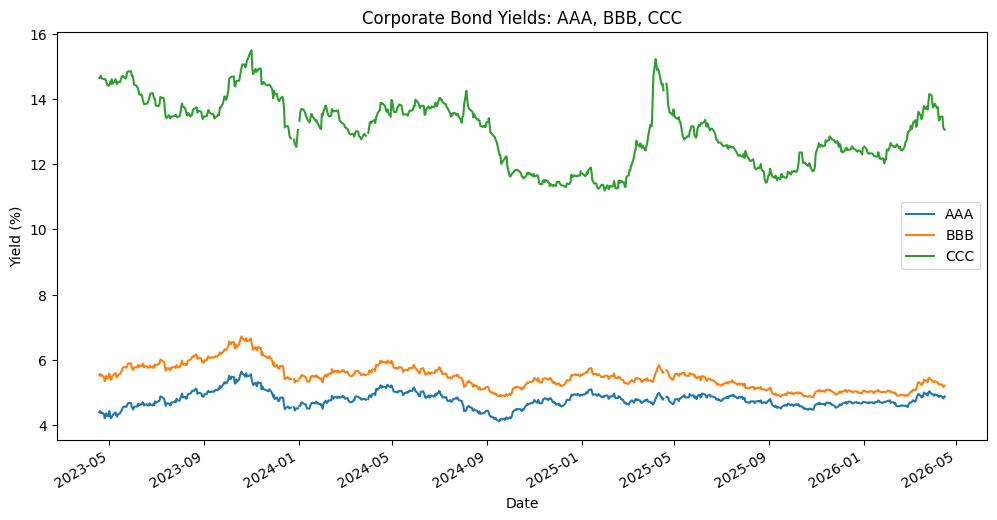

In [4]:
df[["AAA", "BBB", "CCC"]].plot(title="Corporate Bond Yields: AAA, BBB, CCC")
plt.ylabel("Yield (%)")
plt.show()

- AAA lowest
- BBB above AAA
- CCC highest and most volatile

# Step 4 - Plot ETF prices separately
- shows tradable market instruments

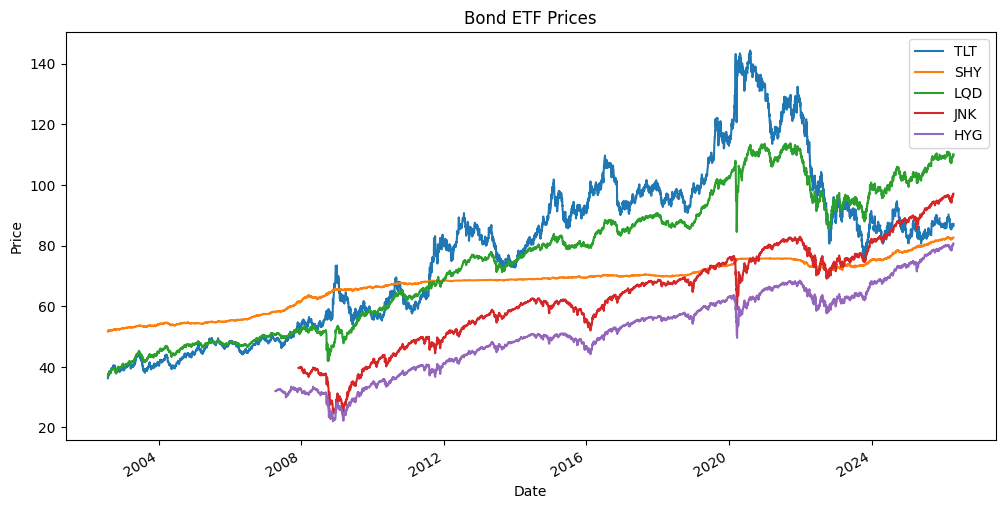

In [5]:
df[["TLT", "SHY", "LQD", "JNK", "HYG"]].plot(title="Bond ETF Prices")
plt.ylabel("Price")
plt.show()

# Step 5 - Create spread columns

In [6]:
df["BBB_minus_AAA"] = df["BBB"] - df["AAA"]
df["CCC_minus_BBB"] = df["CCC"] - df["BBB"]
df["CCC_minus_AAA"] = df["CCC"] - df["AAA"]

#df[["AAA", "BBB", "CCC", "BBB_minus_AAA", "CCC_minus_BBB", "CCC_minus_AAA"]].tail()

__What they mean__
- BBB_minus_AAA = mild credit stress
- CCC_minus_BBB = junk / distressed stress
- CCC_minus_AAA = total credit risk gap

# Step 6 - Plot the spread

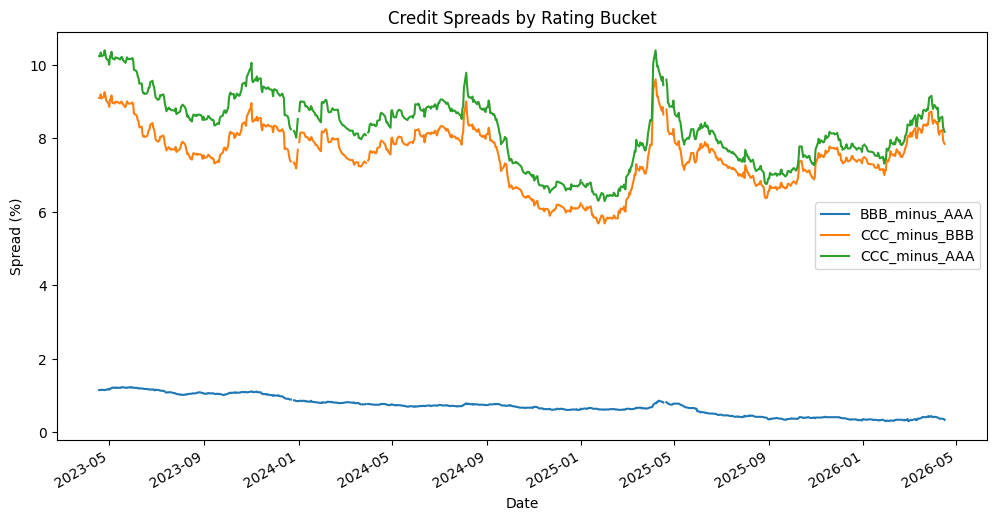

In [7]:
df[["BBB_minus_AAA", "CCC_minus_BBB", "CCC_minus_AAA"]].plot(title="Credit Spreads by Rating Bucket")
plt.ylabel("Spread (%)")
plt.show()

# Step 7 - Create ETF relative strength proxies
- Compare riskier credit ETF's vs safer ones

In [8]:
df["HYG_to_LQD"] = df["HYG"] / df["LQD"]
df["JNK_to_LQD"] = df["JNK"] / df["LQD"]
df["TLT_to_SHY"] = df["TLT"] / df["SHY"]

df[["HYG_to_LQD", "JNK_to_LQD", "TLT_to_SHY"]].tail()

,HYG_to_LQD,JNK_to_LQD,TLT_to_SHY
Date,,,
2026-04-13,0.732166,0.881044,1.051898
2026-04-14,0.731951,0.880797,1.056707
2026-04-15,0.731854,0.880571,1.052357
2026-04-16,0.734259,0.883761,1.046072
2026-04-17,0.732915,0.882225,1.053606


__Interpretation__
- __HYG_to_LQD rising__ = high yield outperforming IG = risk-on
- __JNK_to_LQD rising__ = similar risk-on
- __TLT_to_SHY rising__ = long bonds outperform short bonds

# Step 8 - Plot the ratios

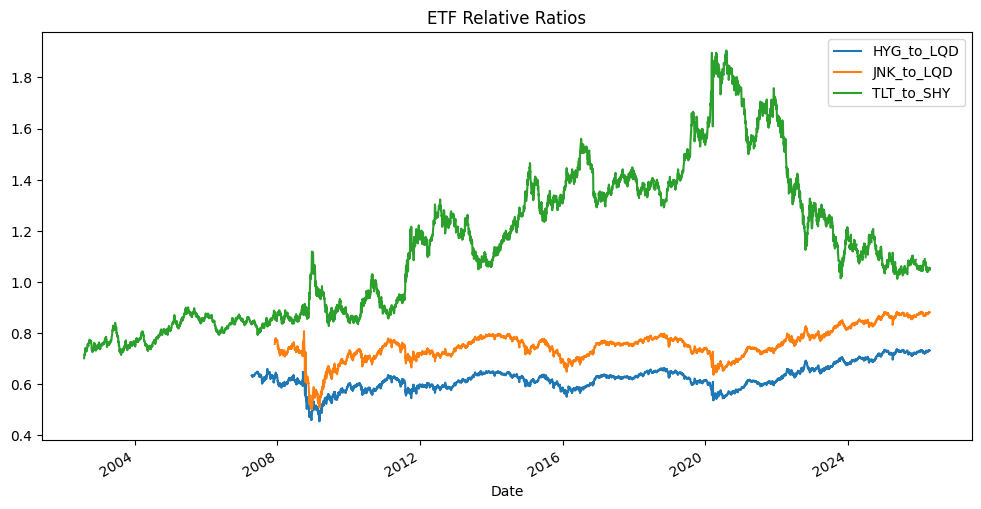

In [9]:
df[["HYG_to_LQD", "JNK_to_LQD", "TLT_to_SHY"]].plot(title="ETF Relative Ratios")
plt.show()

# Step 9 - Add moving averages

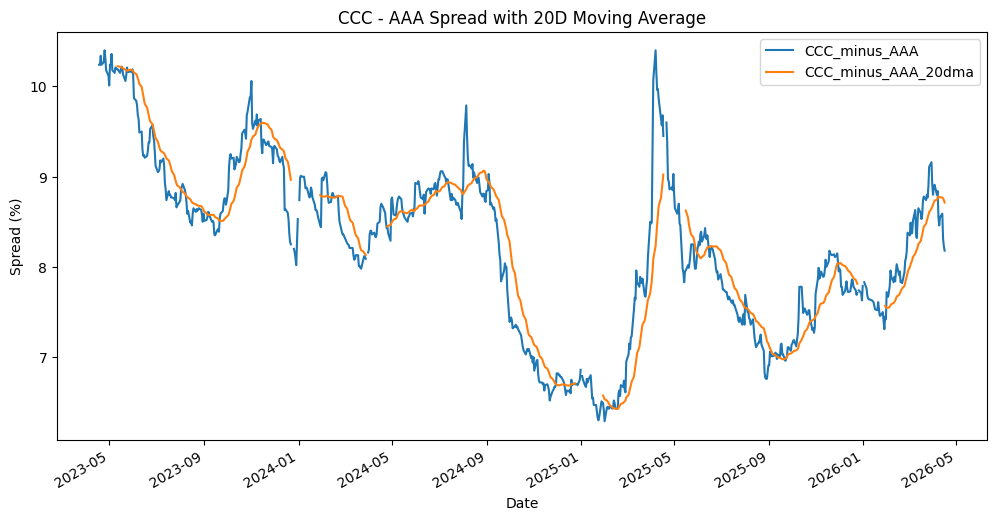

In [10]:
for col in ["BBB_minus_AAA", "CCC_minus_BBB", "CCC_minus_AAA", "HYG_to_LQD", "JNK_to_LQD"]:
    df[f"{col}_20dma"] = df[col].rolling(20).mean()

df[["CCC_minus_AAA", "CCC_minus_AAA_20dma"]].plot(title="CCC - AAA Spread with 20D Moving Average")
plt.ylabel("Spread (%)")
plt.show()

# Step 10 - Interpretation table
- gives current level
- short-term average
- long-term average

In [11]:
latest = pd.DataFrame({
    "Latest": df.iloc[-2],
    "20D Avg": df.tail(20).mean(),
    "60D Avg": df.tail(60).mean()
})

latest.loc[[
    "AAA", "BBB", "CCC",
    "BBB_minus_AAA", "CCC_minus_BBB", "CCC_minus_AAA",
    "HYG_to_LQD", "JNK_to_LQD", "TLT_to_SHY"
]]

,Latest,20D Avg,60D Avg
AAA,4.880000,4.917895,4.780169
BBB,5.210000,5.307368,5.129153
CCC,13.060000,13.627895,13.088136
BBB_minus_AAA,0.330000,0.389474,0.348983
CCC_minus_BBB,7.850000,8.320526,7.958983
CCC_minus_AAA,8.180000,8.710000,8.307966
HYG_to_LQD,0.734259,0.731199,0.728253
JNK_to_LQD,0.883761,0.879483,0.876229
TLT_to_SHY,1.046072,1.050081,1.059874


# Questions

## Creating helper functions

In [12]:
def latest_value(series):
    return series.dropna().iloc[-1]


def previous_value(series, n=1):
    s = series.dropna()
    if len(s) <= n:
        return np.nan
    return s.iloc[-(n + 1)]


def change_over_days(series, days):
    s = series.dropna()
    if len(s) <= days:
        return np.nan
    return s.iloc[-1] - s.iloc[-(days + 1)]


def pct_change_over_days(series, days):
    s = series.dropna()
    if len(s) <= days:
        return np.nan
    prev = s.iloc[-(days + 1)]
    if prev == 0:
        return np.nan
    return (s.iloc[-1] / prev - 1) * 100


def recent_trend(series, days=20, flat_threshold=0.05):
    chg = change_over_days(series, days)
    if pd.isna(chg):
        return "not enough data"
    if chg > flat_threshold:
        return "rising"
    elif chg < -flat_threshold:
        return "falling"
    else:
        return "flat"


def compare_speed(series1, series2, days=20):
    chg1 = change_over_days(series1, days)
    chg2 = change_over_days(series2, days)

    if pd.isna(chg1) or pd.isna(chg2):
        return "not enough data"

    if chg1 > chg2:
        return "faster"
    elif chg1 < chg2:
        return "slower"
    else:
        return "same speed"


def near_recent_high(series, window=60, threshold=0.9):
    s = series.dropna()
    if len(s) < window:
        return "not enough data"

    recent = s.tail(window)
    latest = recent.iloc[-1]
    max_val = recent.max()
    min_val = recent.min()

    if max_val == min_val:
        return "range is flat"

    pos = (latest - min_val) / (max_val - min_val)

    if pos >= threshold:
        return "near recent highs"
    elif pos <= (1 - threshold):
        return "near recent lows"
    else:
        return "mid-range"


def summarize_series(series, name, days=20, flat_threshold=0.05):
    latest = latest_value(series)
    chg_20 = change_over_days(series, days)
    trend = recent_trend(series, days=days, flat_threshold=flat_threshold)

    return {
        "Series": name,
        "Latest": latest,
        f"{days}D Change": chg_20,
        "Trend": trend
    }

df["BBB_minus_AAA"] = df["BBB"] - df["AAA"]
df["CCC_minus_BBB"] = df["CCC"] - df["BBB"]
df["CCC_minus_AAA"] = df["CCC"] - df["AAA"]

df["HYG_to_LQD"] = df["HYG"] / df["LQD"]
df["JNK_to_LQD"] = df["JNK"] / df["LQD"]
df["TLT_to_SHY"] = df["TLT"] / df["SHY"]

# Q1.1 - Yields
- are all yields rising or falling?

In [13]:
yield_summary = pd.DataFrame([
    summarize_series(df["AAA"], "AAA", days=20, flat_threshold=0.10),
    summarize_series(df["BBB"], "BBB", days=20, flat_threshold=0.10),
    summarize_series(df["CCC"], "CCC", days=20, flat_threshold=0.10),
])

yield_summary

,Series,Latest,20D Change,Trend
0,AAA,4.88,0.00,flat
1,BBB,5.21,-0.08,flat
2,CCC,13.06,-0.56,falling


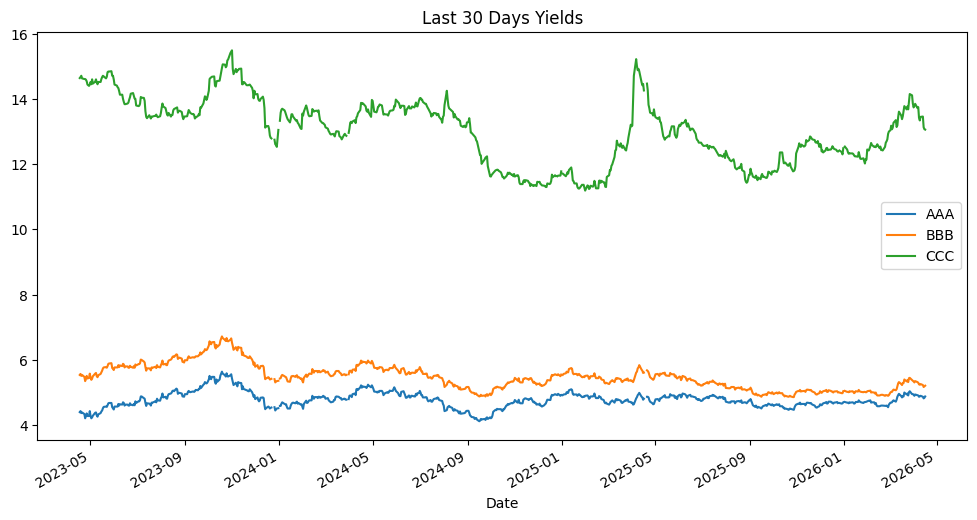

In [14]:
df[["AAA", "BBB", "CCC"]].tail(30)
df[["AAA", "BBB", "CCC"]].plot(title="Last 30 Days Yields")
plt.show()

In [15]:
trends = yield_summary["Trend"].tolist()

if all(t == "rising" for t in trends):
    print("All three yields are rising.")
elif all(t == "falling" for t in trends):
    print("All three yields are falling.")
else:
    print("The yields are mixed, not all moving in the same direction.")

The yields are mixed, not all moving in the same direction.


# Q1.2 - Is CCC rising faster than AAA?

In [16]:
ccc_change = change_over_days(df["CCC"], 20)
aaa_change = change_over_days(df["AAA"], 20)

print(f"CCC 20D change: {ccc_change:.2f}")
print(f"AAA 20D change: {aaa_change:.2f}")

speed_result = compare_speed(df["CCC"], df["AAA"], days=20)

if speed_result == "faster":
    print("CCC is rising faster than AAA.")
elif speed_result == "slower":
    print("CCC is not rising faster than AAA.")
else:
    print(f"Comparison result: {speed_result}.")

CCC 20D change: -0.56
AAA 20D change: 0.00
CCC is not rising faster than AAA.


# Q1.3 - Is BBB_minus_AAA widening?

In [17]:
bbb_aaa_change = change_over_days(df["BBB_minus_AAA"], 20)
bbb_aaa_trend = recent_trend(df["BBB_minus_AAA"], days=20, flat_threshold=0.05)

print(f"BBB_minus_AAA latest: {latest_value(df['BBB_minus_AAA']):.2f}")
print(f"BBB_minus_AAA 20D change: {bbb_aaa_change:.2f}")
print(f"Trend: {bbb_aaa_trend}")

if bbb_aaa_trend == "rising":
    print("BBB_minus_AAA is widening.")
elif bbb_aaa_trend == "falling":
    print("BBB_minus_AAA is tightening.")
else:
    print("BBB_minus_AAA is broadly flat.")

BBB_minus_AAA latest: 0.33
BBB_minus_AAA 20D change: -0.08
Trend: falling
BBB_minus_AAA is tightening.


# Q1.4 - Is CCC_minus_BBB widening sharply?
For “sharply,” use a simple rule:
- rising trend
- and 20D change above its own recent average absolute move

In [18]:
spread = df["CCC_minus_BBB"].dropna()

current_change = change_over_days(spread, 20)
historical_changes = spread.diff(20).abs().dropna().tail(120)
avg_abs_change = historical_changes.mean()

print(f"CCC_minus_BBB latest: {latest_value(spread):.2f}")
print(f"CCC_minus_BBB 20D change: {current_change:.2f}")
print(f"Average absolute 20D move (last 120 obs): {avg_abs_change:.2f}")

if pd.notna(current_change) and pd.notna(avg_abs_change):
    if current_change > avg_abs_change:
        print("CCC_minus_BBB is widening sharply.")
    elif current_change > 0:
        print("CCC_minus_BBB is widening, but not sharply.")
    elif current_change < 0:
        print("CCC_minus_BBB is tightening.")
    else:
        print("CCC_minus_BBB is flat.")
else:
    print("Not enough data.")

CCC_minus_BBB latest: 7.85
CCC_minus_BBB 20D change: -0.48
Average absolute 20D move (last 120 obs): 0.37
CCC_minus_BBB is tightening.


# Q1.5 - Is CCC_minus_AAA near recent highs?

In [19]:
status = near_recent_high(df["CCC_minus_AAA"], window=60, threshold=0.85)

print(f"CCC_minus_AAA latest: {latest_value(df['CCC_minus_AAA']):.2f}")
print(f"Position vs 60D range: {status}")

if status == "near recent highs":
    print("CCC_minus_AAA is near recent highs.")
elif status == "near recent lows":
    print("CCC_minus_AAA is near recent lows.")
else:
    print("CCC_minus_AAA is in the middle of its recent range.")

CCC_minus_AAA latest: 8.18
Position vs 60D range: mid-range
CCC_minus_AAA is in the middle of its recent range.


# Q1.6 - Is HYG_to_LQD falling?

In [20]:
ratio = df["HYG_to_LQD"]

print(f"HYG_to_LQD latest: {latest_value(ratio):.4f}")
print(f"HYG_to_LQD 20D change: {change_over_days(ratio, 20):.4f}")
print(f"Trend: {recent_trend(ratio, days=20, flat_threshold=0.002)}")

if recent_trend(ratio, days=20, flat_threshold=0.002) == "falling":
    print("HYG_to_LQD is falling.")
elif recent_trend(ratio, days=20, flat_threshold=0.002) == "rising":
    print("HYG_to_LQD is rising.")
else:
    print("HYG_to_LQD is broadly flat.")

HYG_to_LQD latest: 0.7329
HYG_to_LQD 20D change: 0.0039
Trend: rising
HYG_to_LQD is rising.


# Q1.7 - Is JNK_to_LQD falling?

In [21]:
ratio = df["JNK_to_LQD"]

print(f"JNK_to_LQD latest: {latest_value(ratio):.4f}")
print(f"JNK_to_LQD 20D change: {change_over_days(ratio, 20):.4f}")
print(f"Trend: {recent_trend(ratio, days=20, flat_threshold=0.002)}")

if recent_trend(ratio, days=20, flat_threshold=0.002) == "falling":
    print("JNK_to_LQD is falling.")
elif recent_trend(ratio, days=20, flat_threshold=0.002) == "rising":
    print("JNK_to_LQD is rising.")
else:
    print("JNK_to_LQD is broadly flat.")

JNK_to_LQD latest: 0.8822
JNK_to_LQD 20D change: 0.0062
Trend: rising
JNK_to_LQD is rising.


# Q1.8 - Is TLT_to_SHY rising or falling?

In [22]:
ratio = df["TLT_to_SHY"]

print(f"TLT_to_SHY latest: {latest_value(ratio):.4f}")
print(f"TLT_to_SHY 20D change: {change_over_days(ratio, 20):.4f}")
print(f"Trend: {recent_trend(ratio, days=20, flat_threshold=0.003)}")

trend = recent_trend(ratio, days=20, flat_threshold=0.003)

if trend == "rising":
    print("TLT_to_SHY is rising.")
elif trend == "falling":
    print("TLT_to_SHY is falling.")
else:
    print("TLT_to_SHY is broadly flat.")

TLT_to_SHY latest: 1.0536
TLT_to_SHY 20D change: -0.0060
Trend: falling
TLT_to_SHY is falling.


In [23]:
diagnostics = []

# Q1
yield_trends = {
    "AAA": recent_trend(df["AAA"], 20, 0.10),
    "BBB": recent_trend(df["BBB"], 20, 0.10),
    "CCC": recent_trend(df["CCC"], 20, 0.10),
}
if all(v == "rising" for v in yield_trends.values()):
    q1_answer = "All yields rising"
elif all(v == "falling" for v in yield_trends.values()):
    q1_answer = "All yields falling"
else:
    q1_answer = "Yields mixed"

diagnostics.append({
    "Question": "Are all yields rising or falling?",
    "Answer": q1_answer
})

# Q2
speed_result = compare_speed(df["CCC"], df["AAA"], days=20)
if speed_result == "faster":
    q2_answer = "Yes, CCC rising faster than AAA"
elif speed_result == "slower":
    q2_answer = "No, CCC not rising faster than AAA"
else:
    q2_answer = speed_result

diagnostics.append({
    "Question": "Is CCC rising faster than AAA?",
    "Answer": q2_answer
})

# Q3
trend = recent_trend(df["BBB_minus_AAA"], 20, 0.05)
diagnostics.append({
    "Question": "Is BBB_minus_AAA widening?",
    "Answer": "Yes" if trend == "rising" else "No" if trend == "falling" else "Flat"
})

# Q4
spread = df["CCC_minus_BBB"].dropna()
current_change = change_over_days(spread, 20)
avg_abs_change = spread.diff(20).abs().dropna().tail(120).mean()
if pd.notna(current_change) and pd.notna(avg_abs_change):
    if current_change > avg_abs_change:
        q4_answer = "Yes, widening sharply"
    elif current_change > 0:
        q4_answer = "Widening, but not sharply"
    elif current_change < 0:
        q4_answer = "No, tightening"
    else:
        q4_answer = "Flat"
else:
    q4_answer = "Not enough data"

diagnostics.append({
    "Question": "Is CCC_minus_BBB widening sharply?",
    "Answer": q4_answer
})

# Q5
diagnostics.append({
    "Question": "Is CCC_minus_AAA near recent highs?",
    "Answer": near_recent_high(df["CCC_minus_AAA"], 60, 0.85)
})

# Q6
trend = recent_trend(df["HYG_to_LQD"], 20, 0.002)
diagnostics.append({
    "Question": "Is HYG_to_LQD falling?",
    "Answer": "Yes" if trend == "falling" else "No" if trend == "rising" else "Flat"
})

# Q7
trend = recent_trend(df["JNK_to_LQD"], 20, 0.002)
diagnostics.append({
    "Question": "Is JNK_to_LQD falling?",
    "Answer": "Yes" if trend == "falling" else "No" if trend == "rising" else "Flat"
})

# Q8
trend = recent_trend(df["TLT_to_SHY"], 20, 0.003)
diagnostics.append({
    "Question": "Is TLT_to_SHY rising or falling?",
    "Answer": trend
})

diagnostics_df = pd.DataFrame(diagnostics)
diagnostics_df

,Question,Answer
0,Are all yields rising or falling?,Yields mixed
1,Is CCC rising faster than AAA?,"No, CCC not rising faster than AAA"
2,Is BBB_minus_AAA widening?,No
3,Is CCC_minus_BBB widening sharply?,"No, tightening"
4,Is CCC_minus_AAA near recent highs?,mid-range
5,Is HYG_to_LQD falling?,No
6,Is JNK_to_LQD falling?,No
7,Is TLT_to_SHY rising or falling?,falling


# Quant layer - Standardized signals

In [24]:
# Z-scores
def zscore(series, window=60):
    return (series - series.rolling(window).mean()) / series.rolling(window).std()
#Apply
df["CCC_AAA_z"] = zscore(df["CCC_minus_AAA"], 60)
df["BBB_AAA_z"] = zscore(df["BBB_minus_AAA"], 60)
df["HYG_LQD_z"] = zscore(df["HYG_to_LQD"], 60)

# percentile ranks
def rolling_percentile(series, window=60):
    return series.rolling(window).apply(
        lambda x: pd.Series(x).rank(pct=True).iloc[-1]
    )

df["CCC_AAA_pct"] = rolling_percentile(df["CCC_minus_AAA"], 60)
df["BBB_AAA_pct"] = rolling_percentile(df["BBB_minus_AAA"], 60)
df["HYG_LQD_pct"] = rolling_percentile(df["HYG_to_LQD"], 60)

#Build a Credit Stress Code
def credit_score(row):
    score = 0

    # Credit spreads (higher = worse)
    if row["CCC_AAA_pct"] > 0.8:
        score += 2
    elif row["CCC_AAA_pct"] > 0.6:
        score += 1

    if row["BBB_AAA_pct"] > 0.8:
        score += 1

    # Risk appetite (lower = worse)
    if row["HYG_LQD_pct"] < 0.2:
        score += 2
    elif row["HYG_LQD_pct"] < 0.4:
        score += 1

    return score


df["Credit_Stress_Score"] = df.apply(credit_score, axis=1)

#Interpret the score
latest_score = df["Credit_Stress_Score"].iloc[-1]

if latest_score >= 4:
    regime = "High stress / risk-off"
elif latest_score >= 2:
    regime = "Moderate stress"
else:
    regime = "Low stress / risk-on"

print(f"Credit regime: {regime}")

Credit regime: Low stress / risk-on


# Create output for Claude

In [25]:
# Function to build the text
def build_claude_summary(df):
    # --- YIELDS ---
    aaa_trend = recent_trend(df["AAA"], 20, 0.10)
    bbb_trend = recent_trend(df["BBB"], 20, 0.10)
    ccc_trend = recent_trend(df["CCC"], 20, 0.10)

    aaa_chg = change_over_days(df["AAA"], 20)
    bbb_chg = change_over_days(df["BBB"], 20)
    ccc_chg = change_over_days(df["CCC"], 20)

    # --- SPREADS ---
    bbb_aaa_trend = recent_trend(df["BBB_minus_AAA"], 20, 0.05)
    ccc_bbb_change = change_over_days(df["CCC_minus_BBB"], 20)
    ccc_aaa_status = near_recent_high(df["CCC_minus_AAA"], 60, 0.85)

    # --- MARKET RATIOS ---
    hyg_trend = recent_trend(df["HYG_to_LQD"], 20, 0.002)
    jnk_trend = recent_trend(df["JNK_to_LQD"], 20, 0.002)
    tlt_trend = recent_trend(df["TLT_to_SHY"], 20, 0.003)

    # =========================
    # MACRO SIGNAL MAPPING
    # =========================

    # Growth:
    # worsening lower-quality credit usually implies weaker growth expectations
    if (
        ccc_trend == "rising"
        and bbb_aaa_trend == "rising"
        and (hyg_trend == "falling" or jnk_trend == "falling")
    ):
        growth_signal = "↓"
    elif (
        ccc_trend == "falling"
        and bbb_aaa_trend == "falling"
        and (hyg_trend == "rising" or jnk_trend == "rising")
    ):
        growth_signal = "↑"
    else:
        growth_signal = "mixed"

    # Inflation:
    # this dataset is not a primary inflation dataset, so use only broad credit/yield tone
    if aaa_trend == "rising" and bbb_trend == "rising" and ccc_trend == "rising":
        inflation_signal = "↑"
    elif aaa_trend == "falling" and bbb_trend == "falling" and ccc_trend == "falling":
        inflation_signal = "↓"
    else:
        inflation_signal = "mixed"

    # Liquidity:
    # widening spreads + weak HY relative performance = tighter conditions
    if (
        bbb_aaa_trend == "rising"
        and (hyg_trend == "falling" or jnk_trend == "falling")
    ):
        liquidity_signal = "Tight"
    elif (
        bbb_aaa_trend == "falling"
        and (hyg_trend == "rising" or jnk_trend == "rising")
    ):
        liquidity_signal = "Loose"
    else:
        liquidity_signal = "Mixed"

    # --- CONCLUSION ---
    if growth_signal == "↓" and liquidity_signal == "Tight":
        conclusion = "Credit conditions deteriorating, risk-off environment."
    elif growth_signal == "↑" and liquidity_signal == "Loose":
        conclusion = "Credit conditions improving, risk-on environment."
    else:
        conclusion = "Mixed credit conditions."

    # --- TEXT OUTPUT ---
    text = f"""
Corporate Credit & Liquidity Summary

Macro Mapping:
Growth: {growth_signal}
Inflation: {inflation_signal}
Liquidity: {liquidity_signal}

Yields:
AAA: {aaa_trend} ({aaa_chg:.2f} over 20D)
BBB: {bbb_trend} ({bbb_chg:.2f} over 20D)
CCC: {ccc_trend} ({ccc_chg:.2f} over 20D)

Spreads:
BBB - AAA: {bbb_aaa_trend}
CCC - BBB: {"widening sharply" if ccc_bbb_change > 0.2 else "widening" if ccc_bbb_change > 0 else "tightening"}
CCC - AAA: {ccc_aaa_status}

Market Signals:
HYG / LQD: {hyg_trend}
JNK / LQD: {jnk_trend}
TLT / SHY: {tlt_trend}

Conclusion:
{conclusion}
"""

    return text.strip()
# Generate the summary
summary_text = build_claude_summary(df)
print(summary_text)

from datetime import datetime
from pathlib import Path

# --- Output directory ---
output_dir = Path(r"C:\Users\ivank\Coding\macro_regime_project\outputs\claude")
output_dir.mkdir(parents=True, exist_ok=True)

# --- Dates ---
today_str = datetime.today().strftime("%Y-%m-%d")

# --- Add date to content ---
final_text = f"Date: {today_str}\n\n" + summary_text

# --- File paths ---
latest_file = output_dir / "corporate_credit_summary.txt"
dated_file = output_dir / f"corporate_credit_summary_{today_str}.txt"

# --- Check if latest file already exists ---
if latest_file.exists():
    # Read first line to check date
    with open(latest_file, "r", encoding="utf-8") as f:
        first_line = f.readline().strip()

    if today_str in first_line:
        # Same day → overwrite
        with open(latest_file, "w", encoding="utf-8") as f:
            f.write(final_text)

        print("Overwritten today's file.")
    else:
        # New day → create dated file + update latest
        with open(dated_file, "w", encoding="utf-8") as f:
            f.write(final_text)

        with open(latest_file, "w", encoding="utf-8") as f:
            f.write(final_text)

        print(f"New day → created {dated_file.name} and updated latest file.")
else:
    # First run ever
    with open(dated_file, "w", encoding="utf-8") as f:
        f.write(final_text)

    with open(latest_file, "w", encoding="utf-8") as f:
        f.write(final_text)

    print("First run → created both latest and dated file.")

Corporate Credit & Liquidity Summary

Macro Mapping:
Growth: ↑
Inflation: mixed
Liquidity: Loose

Yields:
AAA: flat (0.00 over 20D)
BBB: flat (-0.08 over 20D)
CCC: falling (-0.56 over 20D)

Spreads:
BBB - AAA: falling
CCC - BBB: tightening
CCC - AAA: mid-range

Market Signals:
HYG / LQD: rising
JNK / LQD: rising
TLT / SHY: falling

Conclusion:
Credit conditions improving, risk-on environment.
First run → created both latest and dated file.
